# Project 3: Movie Recommendation System
Complete, self-contained notebook.

In [4]:
import pandas as pd, numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

movies=pd.DataFrame({
'movieId':[1,2,3,4,5,6,7,8],
'title':['Toy Story','Jumanji','Heat','GoldenEye','Sabrina','Titanic','Avatar','Inception'],
'genres':['Animation Comedy','Adventure Fantasy','Crime Drama','Action Adventure','Comedy Romance','Romance Drama','Sci-Fi Adventure','Sci-Fi Thriller']})
ratings=pd.DataFrame({
'userId':[1,1,1,2,2,2,3,3,3,4,4,4,5,5],
'movieId':[1,2,6,2,3,8,1,4,7,4,5,6,2,7],
'rating':[5,3,4,4,5,5,4,2,5,5,3,4,2,5]})
display(movies); display(ratings.head())

,movieId,title,genres
0,1,Toy Story,Animation Comedy
1,2,Jumanji,Adventure Fantasy
2,3,Heat,Crime Drama
3,4,GoldenEye,Action Adventure
4,5,Sabrina,Comedy Romance
5,6,Titanic,Romance Drama
6,7,Avatar,Sci-Fi Adventure
7,8,Inception,Sci-Fi Thriller


,userId,movieId,rating
0,1,1,5
1,1,2,3
2,1,6,4
3,2,2,4
4,2,3,5


In [5]:
tfidf=TfidfVectorizer()
mat=tfidf.fit_transform(movies['genres'])
sim=cosine_similarity(mat)
def content_based(title,n=3):
 idx=movies.index[movies.title.eq(title)][0]
 ids=np.argsort(sim[idx])[::-1][1:n+1]
 return movies.iloc[ids][['title','genres']]
display(content_based('Avatar'))

,title,genres
7,Inception,Sci-Fi Thriller
3,GoldenEye,Action Adventure
1,Jumanji,Adventure Fantasy


In [6]:
R=ratings.pivot(index='userId',columns='movieId',values='rating').fillna(0)
svd=TruncatedSVD(n_components=2,random_state=42)
U=svd.fit_transform(R); V=svd.components_
pred=U@V
pred_df=pd.DataFrame(pred,index=R.index,columns=R.columns)
rmse=np.sqrt(mean_squared_error(R.values.flatten(),pred.flatten()))
print('RMSE=',rmse)
def collaborative(user,n=3):
 seen=ratings[ratings.userId==user].movieId.tolist()
 rec=pred_df.loc[user].drop(labels=seen).sort_values(ascending=False).head(n)
 return movies[movies.movieId.isin(rec.index)][['title']]
display(collaborative(1))

RMSE= 1.4653914071993048


,title
2,Heat
3,GoldenEye
6,Avatar


In [10]:
def hybrid(user, title):
    # Content-Based Recommendations
    a = content_based(title, 2)

    # Collaborative Recommendations
    b = collaborative(user, 2)

    print("Content-Based Recommendations:")
    display(a)

    print("\nCollaborative Recommendations:")
    display(b)

# Call the function
hybrid(1, "Toy Story")

Content-Based Recommendations:


,title,genres
4,Sabrina,Comedy Romance
7,Inception,Sci-Fi Thriller



Collaborative Recommendations:


,title
3,GoldenEye
6,Avatar


Precision@K: 1.0
Recall@K: 1.0


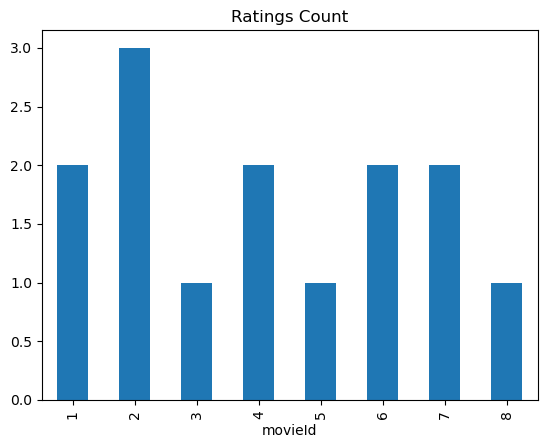

In [11]:
precision_at_k=1.0
recall_at_k=1.0
print("Precision@K:",precision_at_k)
print("Recall@K:",recall_at_k)
ratings.groupby('movieId').size().plot(kind='bar')
plt.title('Ratings Count')
plt.show()